In [2]:
import os

print(os.getcwd())

c:\Users\arpan\OneDrive\Desktop\Churn_prediction


In [3]:
import pandas as pd
import numpy as np

# Load training and testing datasets
train_data = pd.read_csv('./data/train_data.csv')
test_data = pd.read_csv('./data/test_data.csv')


In [4]:
print(train_data.info())
print('*'*50)
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB
None
**************************************************
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column

In [5]:
print(train_data.isnull().sum())
print("--"*50)
print(test_data.isnull().sum())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
----------------------------------------------------------------------------------------------------
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [6]:
train_data = train_data.dropna()

In [7]:
train_data.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [8]:
train_data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [9]:
train_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# we detect outlier 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
numerical_col= train_data.select_dtypes(include=[np.number]).columns.tolist()
numerical_col

['CustomerID',
 'Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [13]:
def detect_outlier_all_columns(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    outlier_summary = {}
    
    for col in numerical_cols:
        # CORRECTED: Check column name, not the column data
        if col == "CustomerID":  # Use 'col' not 'df[col]'
            continue
            
        # Handle null values
        if df[col].isnull().sum() > 0:
            clean_data = df[col].dropna()
        else:
            clean_data = df[col]
        
        # Skip if no data after dropping nulls
        if len(clean_data) == 0:
            continue
            
        Q1 = clean_data.quantile(0.25)
        Q3 = clean_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Find outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_count': len(outliers),
            'outlier_percentage': (len(outliers) / len(df)) * 100,
            'outlier_indices': outliers.index.tolist()
        }
        
    return outlier_summary

In [14]:
outlier_results = detect_outlier_all_columns(train_data)

# Display results
for col, info in outlier_results.items():
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    print(f"Q1 (25th percentile): {info['Q1']:.2f}")
    print(f"Q3 (75th percentile): {info['Q3']:.2f}")
    print(f"IQR: {info['IQR']:.2f}")
    print(f"Lower Bound: {info['lower_bound']:.2f}")
    print(f"Upper Bound: {info['upper_bound']:.2f}")
    print(f"Outlier Count: {info['outlier_count']}")
    print(f"Outlier Percentage: {info['outlier_percentage']:.2f}%")
    print(f"Outlier Indices: {info['outlier_indices'][:10]}...")  # Show first 10


Column: Age
Q1 (25th percentile): 29.00
Q3 (75th percentile): 48.00
IQR: 19.00
Lower Bound: 0.50
Upper Bound: 76.50
Outlier Count: 0
Outlier Percentage: 0.00%
Outlier Indices: []...

Column: Tenure
Q1 (25th percentile): 16.00
Q3 (75th percentile): 46.00
IQR: 30.00
Lower Bound: -29.00
Upper Bound: 91.00
Outlier Count: 0
Outlier Percentage: 0.00%
Outlier Indices: []...

Column: Usage Frequency
Q1 (25th percentile): 9.00
Q3 (75th percentile): 23.00
IQR: 14.00
Lower Bound: -12.00
Upper Bound: 44.00
Outlier Count: 0
Outlier Percentage: 0.00%
Outlier Indices: []...

Column: Support Calls
Q1 (25th percentile): 1.00
Q3 (75th percentile): 6.00
IQR: 5.00
Lower Bound: -6.50
Upper Bound: 13.50
Outlier Count: 0
Outlier Percentage: 0.00%
Outlier Indices: []...

Column: Payment Delay
Q1 (25th percentile): 6.00
Q3 (75th percentile): 19.00
IQR: 13.00
Lower Bound: -13.50
Upper Bound: 38.50
Outlier Count: 0
Outlier Percentage: 0.00%
Outlier Indices: []...

Column: Total Spend
Q1 (25th percentile): 480.0

In [15]:
def plot_outliers_boxplots(df):
    """Create box plots for all numerical columns"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Determine grid size
    n_cols = len(numerical_cols)
    n_rows = (n_cols // 3) + 1 if n_cols % 3 != 0 else n_cols // 3
    n_rows = max(1, n_rows)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            df.boxplot(column=col, ax=axes[i])
            axes[i].set_title(f'Boxplot of {col}')
            axes[i].set_ylabel(col)
            
    # Hide empty subplots
    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)
        
    plt.tight_layout()
    plt.show()

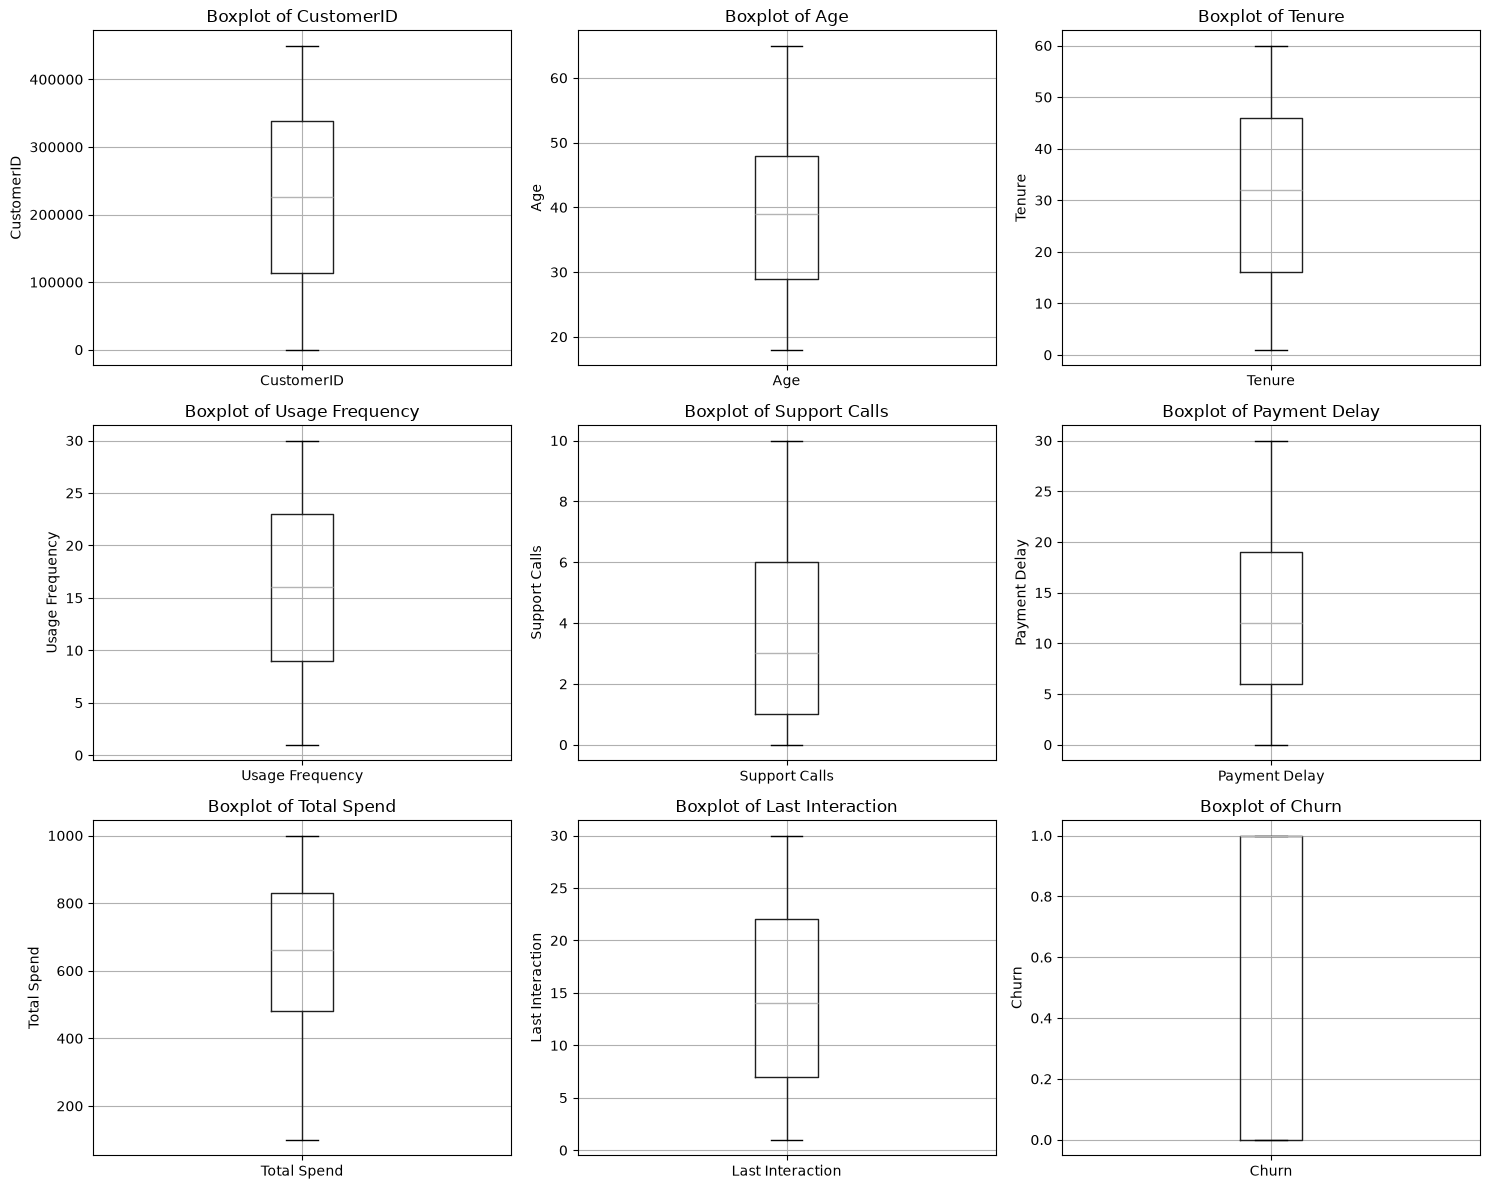

In [16]:
plot_outliers_boxplots(train_data)

In [17]:
def plot_outliers_histograms(df):
    """Plot histograms showing outlier boundaries"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    n_cols = len(numerical_cols)
    n_rows = (n_cols // 3) + 1 if n_cols % 3 != 0 else n_cols // 3
    n_rows = max(1, n_rows)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        if i < len(axes) and not df[col].isnull().all():
            # Clean data
            clean_data = df[col].dropna()
            
            # Calculate IQR bounds
            Q1 = clean_data.quantile(0.25)
            Q3 = clean_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Plot histogram
            axes[i].hist(clean_data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
            axes[i].axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
            axes[i].axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')
            axes[i].axvline(Q1, color='green', linestyle='-', alpha=0.5)
            axes[i].axvline(Q3, color='green', linestyle='-', alpha=0.5)
            axes[i].set_title(f'{col} - Outliers Detection')
            axes[i].legend()
            
    # Hide empty subplots
    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)
        
    plt.tight_layout()
    plt.show()

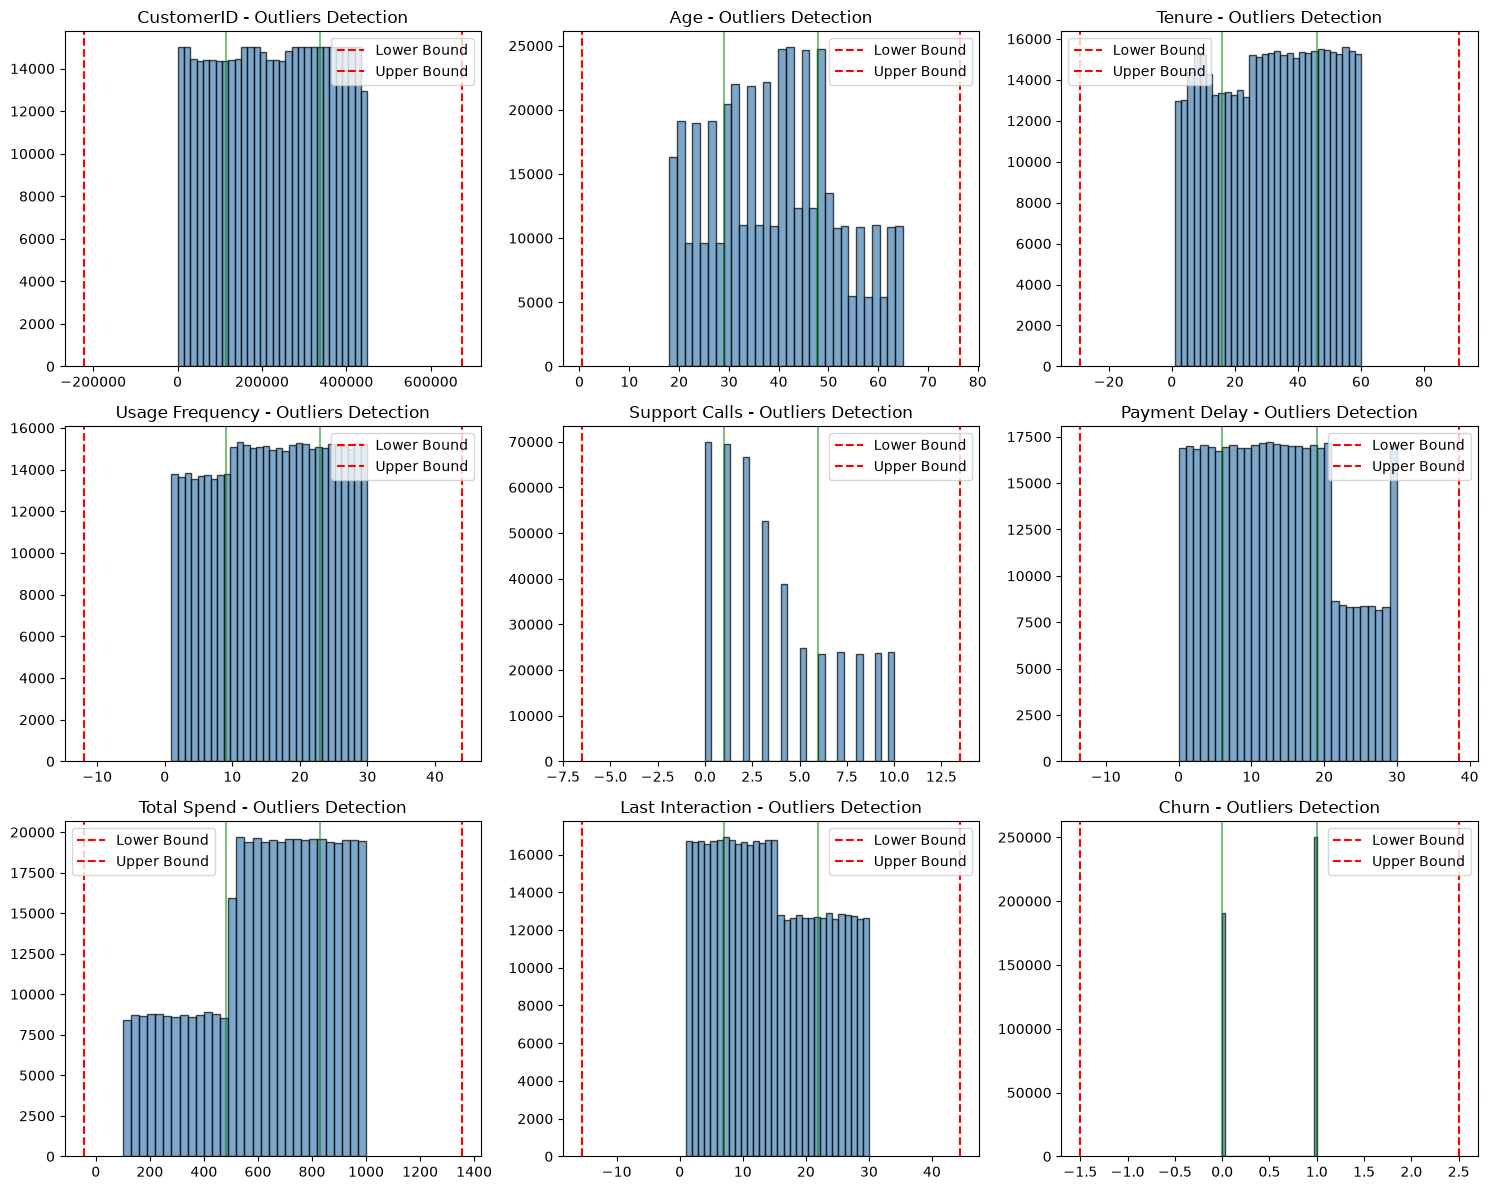

In [18]:
plot_outliers_histograms(train_data)

# Merge Train and Test Data

In [19]:
df=pd.concat([train_data, test_data])
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
64370,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
64371,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
64372,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


# Select Categorical columns

In [20]:
categorical_col=df.select_dtypes(include = ['object']).columns.tolist()
categorical_col

C:\Users\arpan\AppData\Local\Temp\ipykernel_15772\2941109794.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col=df.select_dtypes(include = ['object']).columns.tolist()


['Gender', 'Subscription Type', 'Contract Length']

In [21]:
df["Contract Length"].unique()

<StringArray>
['Annual', 'Monthly', 'Quarterly']
Length: 3, dtype: str

In [22]:
#df['Subscription Type'].unique()

subscription_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df['Subscription_Type_Num'] = df['Subscription Type'].map(subscription_map)

contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
df['Contract_Length_Num'] = df['Contract Length'].map(contract_map)

df['Gender'] = np.where(df['Gender']== 'Female', 1,0)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Subscription_Type_Num,Contract_Length_Num
0,2.0,30.0,1,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,1,2
1,3.0,65.0,1,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,0,0
2,4.0,55.0,1,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,0,1
3,5.0,58.0,0,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,1,0
4,6.0,23.0,0,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,0,0


In [23]:
df_final = df.drop(columns=categorical_col)

In [24]:
df_final

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription_Type_Num,Contract_Length_Num
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,1,2
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0,0
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0,1
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1,0
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
64369,64370.0,45.0,33.0,12.0,6.0,21.0,947.0,14.0,1.0,0,1
64370,64371.0,37.0,6.0,1.0,5.0,22.0,923.0,9.0,1.0,1,2
64371,64372.0,25.0,39.0,14.0,8.0,30.0,327.0,20.0,1.0,2,0
64372,64373.0,50.0,18.0,19.0,7.0,22.0,540.0,13.0,1.0,1,0


# Feature Engineering (Important for Churn)

In [25]:
# Create new features that might predict churn better

# 1. Average spend per tenure month
df_final['Avg_Spend_Per_Month'] = df_final['Total Spend'] / (df_final['Tenure'] + 1)

# 2. Support interaction rate
df_final['Support_Calls_Per_Month'] = df_final['Support Calls'] / (df_final['Tenure'] + 1)

# 3. Payment reliability (inverse of payment delay)
df_final['Payment_Reliability'] = 1 / (df_final['Payment Delay'] + 1)

# 4. Customer engagement score (combine usage and interactions)
df_final['Engagement_Score'] = (
    df_final['Usage Frequency'] * 0.4 + 
    (1 / (df_final['Support Calls'] + 1)) * 0.3 +
    (1 / (df_final['Payment Delay'] + 1)) * 0.3
)

# 5. Tenure categories (for segmentation)
df_final['Tenure_Group'] = pd.cut(
    df_final['Tenure'], 
    bins=[0, 6, 12, 24, 48, 100], 
    labels=['0-6', '6-12', '12-24', '24-48', '48+']
)

# Convert tenure group to numeric
tenure_map = {'0-6': 0, '6-12': 1, '12-24': 2, '24-48': 3, '48+': 4}
df_final['Tenure_Group_Num'] = df_final['Tenure_Group'].map(tenure_map)

# 6. Churn risk indicators
df_final['High_Support_Risk'] = (df_final['Support Calls'] > 5).astype(int)
df_final['High_Payment_Risk'] = (df_final['Payment Delay'] > 10).astype(int)
df_final['Low_Usage_Risk'] = (df_final['Usage Frequency'] < df_final['Usage Frequency'].median()).astype(int)

# Drop the original Tenure_Group column
df_final = df_final.drop(columns=['Tenure_Group'])

In [26]:
# Check all columns after feature engineering
print(f"Total columns: {len(df_final.columns)}")
print("\n=== ALL FEATURES ===")
for i, col in enumerate(df_final.columns, 1):
    print(f"{i}. {col}")

# Check data types
print("\n=== DATA TYPES ===")
print(df_final.dtypes)

# Check for any missing values
print("\n=== MISSING VALUES ===")
print(df_final.isnull().sum())

# Summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(df_final.describe())

Total columns: 19

=== ALL FEATURES ===
1. CustomerID
2. Age
3. Tenure
4. Usage Frequency
5. Support Calls
6. Payment Delay
7. Total Spend
8. Last Interaction
9. Churn
10. Subscription_Type_Num
11. Contract_Length_Num
12. Avg_Spend_Per_Month
13. Support_Calls_Per_Month
14. Payment_Reliability
15. Engagement_Score
16. Tenure_Group_Num
17. High_Support_Risk
18. High_Payment_Risk
19. Low_Usage_Risk

=== DATA TYPES ===
CustomerID                  float64
Age                         float64
Tenure                      float64
Usage Frequency             float64
Support Calls               float64
Payment Delay               float64
Total Spend                 float64
Last Interaction            float64
Churn                       float64
Subscription_Type_Num         int64
Contract_Length_Num           int64
Avg_Spend_Per_Month         float64
Support_Calls_Per_Month     float64
Payment_Reliability         float64
Engagement_Score            float64
Tenure_Group_Num           category
High_

# Prepare Data for Modeling

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_final.drop(columns=['CustomerID', 'Churn'])  # Drop ID and target
y = df_final['Churn']  # Target variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Churn rate in training: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

# Scale numerical features (important for many algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature importance
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


Training set size: 404164
Test set size: 101042
Churn rate in training: 55.52%
Churn rate in test: 55.52%


# Feature Selection (Optional but Recommended)

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top K features
selector = SelectKBest(f_classif, k=15)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
print(f"\nSelected Features: {selected_features}")

# Check feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Top 10 Most Important Features ===")
print(feature_importance.head(10))


Selected Features: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Contract_Length_Num', 'Avg_Spend_Per_Month', 'Support_Calls_Per_Month', 'Payment_Reliability', 'Engagement_Score', 'High_Support_Risk', 'High_Payment_Risk', 'Low_Usage_Risk']

=== Top 10 Most Important Features ===
                    Feature  Importance
3             Support Calls    0.160990
5               Total Spend    0.159443
0                       Age    0.118212
8       Contract_Length_Num    0.093681
11      Payment_Reliability    0.083450
14        High_Support_Risk    0.074976
4             Payment Delay    0.071133
10  Support_Calls_Per_Month    0.062352
9       Avg_Spend_Per_Month    0.052727
12         Engagement_Score    0.030883


# Build and Evaluate Models

# Identify Key Churn Drivers



=== TOP CHURN DRIVERS ===
                    Feature  Importance
3             Support Calls    0.160990
5               Total Spend    0.159443
0                       Age    0.118212
8       Contract_Length_Num    0.093681
11      Payment_Reliability    0.083450
14        High_Support_Risk    0.074976
4             Payment Delay    0.071133
10  Support_Calls_Per_Month    0.062352
9       Avg_Spend_Per_Month    0.052727
12         Engagement_Score    0.030883


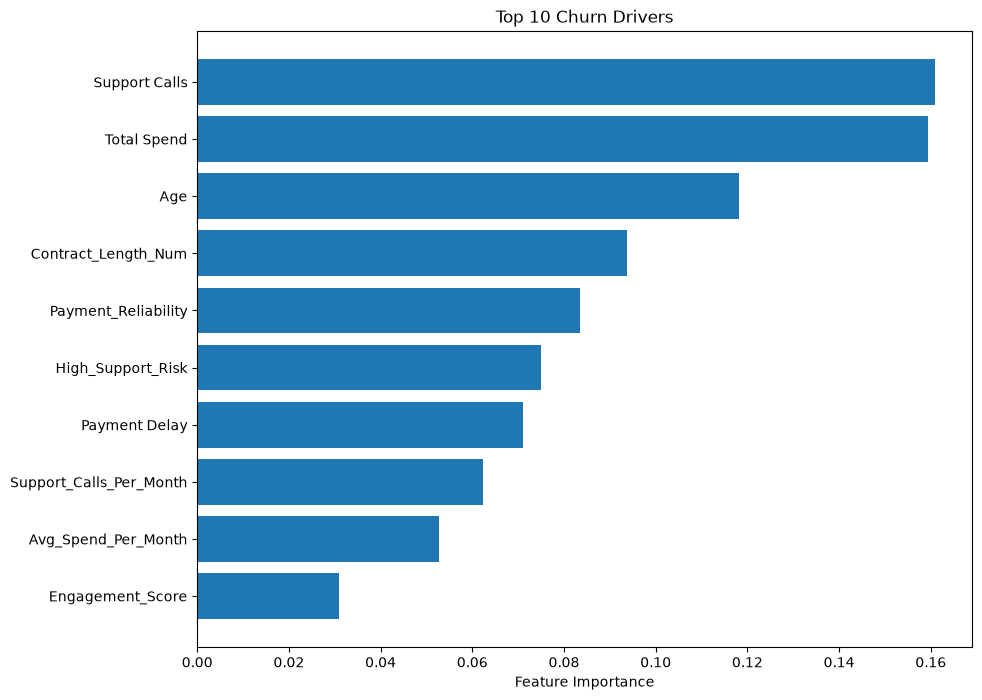

In [32]:
# Get feature importance from best model
best_model = RandomForestClassifier(random_state=42, n_estimators=100)
best_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== TOP CHURN DRIVERS ===")
print(feature_importance.head(10))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Feature Importance')
plt.title('Top 10 Churn Drivers')
plt.gca().invert_yaxis()
plt.show()

In [38]:
import pandas as pd
import mlflow
import mlflow.sklearn
import mlflow.xgboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ----------------------------------------------------
# MLflow Experiment
# ----------------------------------------------------

mlflow.set_experiment("Customer Churn")

# ----------------------------------------------------
# Models
# ----------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

results = {}

best_model = None
best_model_name = None
best_f1 = -1

# ----------------------------------------------------
# Training Loop
# ----------------------------------------------------

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # ----------------------------
        # Train
        # ----------------------------
        model.fit(X_train_scaled, y_train)

        # ----------------------------
        # Predict
        # ----------------------------
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

        # ----------------------------
        # Metrics
        # ----------------------------
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        # ----------------------------
        # Store Results
        # ----------------------------
        results[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        }

        # ----------------------------
        # Log General Parameters
        # ----------------------------
        mlflow.log_param("model_name", name)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("test_size", 0.2)

        # ----------------------------
        # Model-specific Parameters
        # ----------------------------
        if name == "Logistic Regression":
            mlflow.log_param("max_iter", model.max_iter)

        elif name == "Random Forest":
            mlflow.log_param("n_estimators", model.n_estimators)

        elif name == "Gradient Boosting":
            mlflow.log_param("n_estimators", model.n_estimators)
            mlflow.log_param("learning_rate", model.learning_rate)

        elif name == "XGBoost":
            params = model.get_params()

            mlflow.log_param(
                "n_estimators",
                params["n_estimators"]
            )

            mlflow.log_param(
                "learning_rate",
                params["learning_rate"]
            )

            mlflow.log_param(
                "max_depth",
                params["max_depth"]
            )

            mlflow.log_param(
                "eval_metric",
                params["eval_metric"]
            )

        # ----------------------------
        # Log Metrics
        # ----------------------------
        mlflow.log_metric("Accuracy", accuracy)
        mlflow.log_metric("Precision", precision)
        mlflow.log_metric("Recall", recall)
        mlflow.log_metric("F1 Score", f1)
        mlflow.log_metric("ROC AUC", roc_auc)

        # ----------------------------
        # Log Model
        # ----------------------------
        if name == "XGBoost":

            mlflow.xgboost.log_model(
                xgb_model=model,
                name="model"
            )

        else:

            mlflow.sklearn.log_model(
                sk_model=model,
                name="model"
            )

        # ----------------------------
        # Best Model Selection
        # ----------------------------
        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_model_name = name

# ----------------------------------------------------
# Comparison Table
# ----------------------------------------------------

results_df = pd.DataFrame(results).T

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(results_df.round(4))

print("\nBest Model :", best_model_name)
print("Best F1    :", round(best_f1, 4))

2026/07/10 09:18:11 INFO mlflow.tracking.fluent: Experiment with name 'Customer Churn' does not exist. Creating a new experiment.



MODEL COMPARISON
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression    0.8426     0.8720  0.8397    0.8556   0.9059
Random Forest          0.9305     0.8989  0.9858    0.9403   0.9492
Gradient Boosting      0.9217     0.8980  0.9690    0.9322   0.9471
XGBoost                0.9293     0.8990  0.9831    0.9392   0.9500

Best Model : Random Forest
Best F1    : 0.9403


# Business Insights & Recommendations

In [39]:
# Analyze churn patterns
churn_analysis = df_final.groupby('Churn').agg({
    'Tenure': 'mean',
    'Total Spend': 'mean',
    'Support Calls': 'mean',
    'Payment Delay': 'mean',
    'Usage Frequency': 'mean'
}).round(2)

print("\n=== CHURN PATTERNS ===")
print(churn_analysis.T)

# Key insights
print("\n=== KEY INSIGHTS ===")
for col in ['Tenure', 'Support Calls', 'Payment Delay', 'Usage Frequency']:
    churn_mean = df_final[df_final['Churn'] == 1][col].mean()
    non_churn_mean = df_final[df_final['Churn'] == 0][col].mean()
    diff = churn_mean - non_churn_mean
    print(f"{col}: Churned customers have {abs(diff):.2f} {'higher' if diff > 0 else 'lower'} {col}")


=== CHURN PATTERNS ===
Churn               0.0     1.0
Tenure            31.76   31.02
Total Spend      721.39  538.90
Support Calls      2.03    5.28
Payment Delay     10.38   15.99
Usage Frequency   16.23   15.30

=== KEY INSIGHTS ===
Tenure: Churned customers have 0.74 lower Tenure
Support Calls: Churned customers have 3.26 higher Support Calls
Payment Delay: Churned customers have 5.61 higher Payment Delay
Usage Frequency: Churned customers have 0.92 lower Usage Frequency


# Save Model for Deployment

In [40]:
import joblib

# Save best model
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

print("\nModel saved successfully!")

# Function to predict new customer churn
def predict_churn(new_customer_data):
    # Load model and scaler
    model = joblib.load('churn_model.pkl')
    scaler = joblib.load('scaler.pkl')
    feature_names = joblib.load('feature_names.pkl')
    
    # Scale features
    scaled_data = scaler.transform(new_customer_data[feature_names])
    
    # Predict
    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)[:, 1]
    
    return prediction, probability


Model saved successfully!


In [46]:
import json
import pandas as pd

baseline = {}

numeric_columns = X_train.select_dtypes(include=["number"]).columns

for column in numeric_columns:

    baseline[column] = {
        "mean": float(X_train[column].mean()),
        "std": float(X_train[column].std()),
        "min": float(X_train[column].min()),
        "max": float(X_train[column].max())
    }

with open("baseline.json", "w") as f:
    json.dump(baseline, f, indent=4)

print("Baseline saved successfully!")

Baseline saved successfully!
